In [1]:
using Pkg
Pkg.activate(".")

using Base.Threads
using LinearAlgebra, Random, StatsBase, SparseArrays
using CUDA, KernelAbstractions, Adapt, GPUArrays
using Plots, StatsPlots
using Clustering
using JLD2

using DictionaryLearning

include("../examples/debug.jl")

# plot theme
theme(:rose_pine)

# choose backend
back = CUDA.functional() ? CUDABackend() : CPU()

# set threads
BLAS.set_num_threads(nthreads())

println("$INF backend: $back")
println("$INF # threads: $(nthreads())")

  Activating project at `~/DictionaryLearning/experiments`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[INF] backend: CUDABackend(false, false)
[INF] # threads: 32


In [2]:
@load "../temp/fl-example/fls.jld2" fls
D = fls.G
normalize!.(eachcol(D))

m, k = size(D)
s = 3
n = 10000
t = 4000

println("$INF m = $m")
println("$INF k = $k")
println("$INF n = $n")
println("$INF t = $t")
println("$INF s = $s")
println("$INF sizeof(Y) = $(m*n*sizeof(eltype(D))*1e-9)GB")
;

[INF] m = 255
[INF] k = 169
[INF] n = 10000
[INF] t = 4000
[INF] s = 3
[INF] sizeof(Y) = 0.0408GB


In [3]:
D = adapt(back, D)
X_cpu = gen_sparse_samples(eltype(D), k, n, s)
X = adapt(back, X_cpu)
Y = D*X
;

In [5]:
gs = GELMAStruct(
    D, Y, k, 
    0.5,                   # sparsity regularization parameter
    eps=1e-2,               # termination error threshold
    dt=0.01,                 # step size
    max_iters=1000,         # maximum allowed iterations
    sparse_ls_cutoff=0.1    # sparsity to start using conjugate gradient
)
gws = GELMAWorkStruct(gs)
gelma!(gs, gws)
;

[INF] L1 error of final iterations:  0.029564769671859763
[INF] sparsities of final iterations: 2.1900411764705883


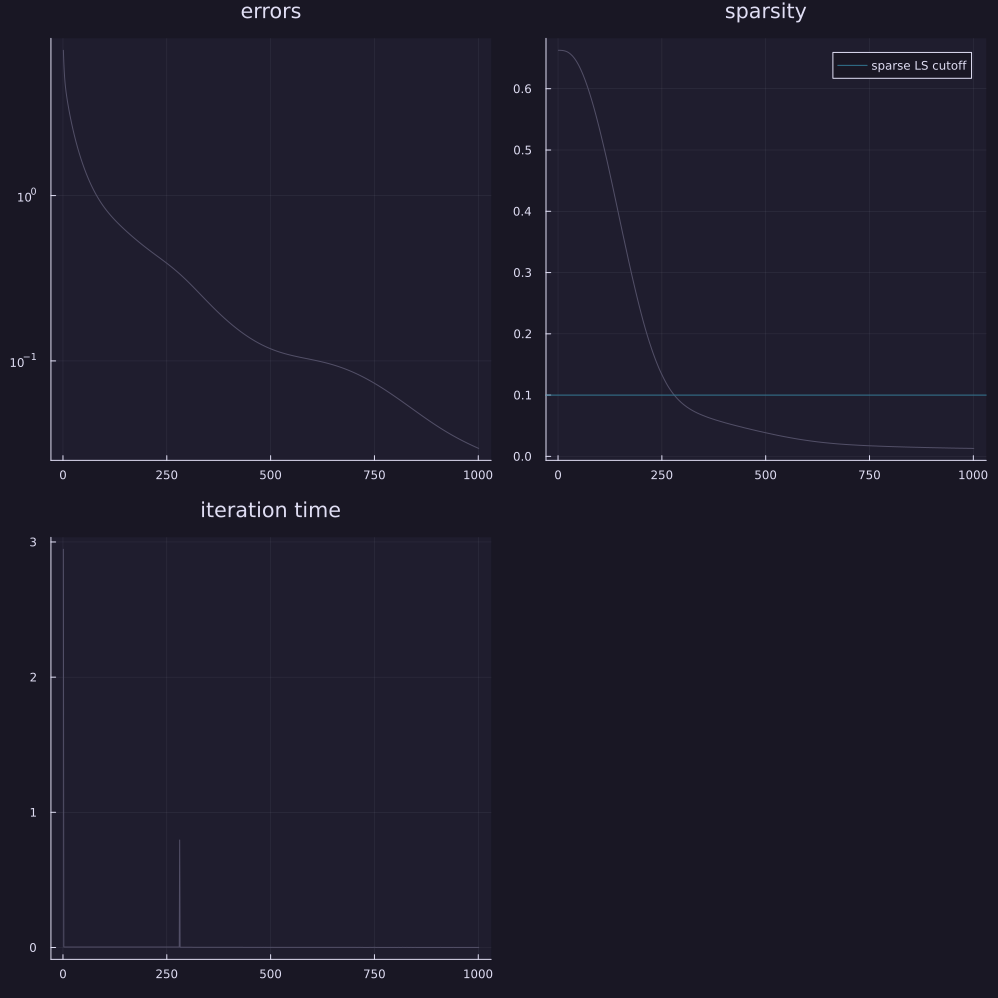

In [6]:
println("$INF L1 error of final iterations:  $(last(gs.err_hist))")
println("$INF sparsities of final iterations: $(k*last(gs.sparsity_hist))")

let
    p1 = plot(gs.err_hist, yscale=:log10, label=:none, title="errors")
    p2 = plot(gs.sparsity_hist, label=:none, title="sparsity")
    hline!([gs.sparse_ls_cutoff], label="sparse LS cutoff")
    p3 = plot(gs.elap_hist, label=:none, title="iteration time")

    plot(p1, p2, p3, layout=(2, 2), size=(1000, 1000))
end